<a href="https://colab.research.google.com/github/isra-data-analytics/isra-data-analytics/blob/main/apartamentos_18_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =============================================================================
# LIBRERÍAS NECESARIAS
# =============================================================================

# Tratamiento de datos
# -----------------------------------------------------------------------------
import numpy as np          # Manejo de arrays y operaciones numéricas eficientes
import pandas as pd         # Manipulación y análisis de datos estructurados
from tabulate import tabulate   # Formateo de tablas para mejor visualización
from scipy import stats

# Gráficos
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt         # Librería base para visualizaciones
from matplotlib import style           # Estilos para gráficos
import matplotlib.ticker as ticker     # Formateo de ejes en gráficos
import seaborn as sns                 # Visualizaciones estadísticas avanzadas
import statsmodels.api as sm          # Modelos estadísticos y econométricos

# Configuración matplotlib
# -----------------------------------------------------------------------------
plt.rcParams['image.cmap'] = "bwr"    # Configura el mapa de colores predeterminado
plt.rcParams['savefig.bbox'] = "tight"  # Ajusta los márgenes al guardar figuras
style.use('ggplot') or plt.style.use('ggplot')  # Establece estilo visual ggplot

# Configuración warnings
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')  # Desactiva mensajes de advertencia
# pd.options.display.float_format = '{:.2f}'.format # Suprimir notación cientifica en python

In [3]:
pip install stats

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.6/127.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stats: filename=stats-0.1.2a0-py3-none-any.whl size=24283 sha256=1a2d9f54acb32dae736349793c8144177823c8fa84bd3afe50f2437f929a6114
  Stored in directory: /root/.cache/pip/wheels/cf/4f/48/be81fb2b5f67ca31d8bfe2e92a9ff516bd21a4824c85b19f5f
Successfully built stats


# Lectura de tablas

In [4]:
# Ruta base
ruta_base = r"/content/drive/MyDrive/Konrad Lorenz/Semestre II/ML/in"

# Cargar los archivos

variables_categoricas = pd.read_excel(f"{ruta_base}/Variables Categoricas.xlsx")
variables_numericas = pd.read_excel(f"{ruta_base}/Variables Numericas.xlsx")

In [5]:
variables_categoricas.head()

,tipo_propiedad,localidad,sector,barrio,antiguedad,tipo_operacion
0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,ENTRE 10 Y 20 ANOS,VENTA
1,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,MAS DE 20 ANOS,VENTA
2,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,ENTRE 0 Y 5 ANOS,VENTA
3,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,ENTRE 10 Y 20 ANOS,VENTA
4,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,MAS DE 20 ANOS,VENTA


In [6]:
variables_numericas.head()

,precio_venta,area,habitaciones,banos,parqueaderos,estrato
0,339000000.0,76.0,3,2,1,3
1,223000000.0,63.0,3,2,0,3
2,440898168.0,54.0,3,2,0,3
3,158000000.0,43.0,2,2,0,2
4,222800000.0,48.0,3,2,0,3


In [7]:
# Combinar los DataFrames
df = pd.concat([variables_numericas, variables_categoricas], axis=1)
df.head()

,precio_venta,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,antiguedad,tipo_operacion
0,339000000.0,76.0,3,2,1,3,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,ENTRE 10 Y 20 ANOS,VENTA
1,223000000.0,63.0,3,2,0,3,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,MAS DE 20 ANOS,VENTA
2,440898168.0,54.0,3,2,0,3,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,ENTRE 0 Y 5 ANOS,VENTA
3,158000000.0,43.0,2,2,0,2,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,ENTRE 10 Y 20 ANOS,VENTA
4,222800000.0,48.0,3,2,0,3,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,MAS DE 20 ANOS,VENTA


In [8]:
print(variables_categoricas.shape)
print(variables_numericas.shape)

(43013, 6)
(43013, 6)


In [9]:
df['antiguedad'].unique()

array(['ENTRE 10 Y 20 ANOS', 'MAS DE 20 ANOS', 'ENTRE 0 Y 5 ANOS',
       'ENTRE 5 Y 10 ANOS', 'REMODELADO', 'PARA ESTRENAR', 'SOBRE PLANOS',
       'EN CONSTRUCCION', "{'$numberDouble': 'NaN'}"], dtype=object)

In [10]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 0 Y 5 ANOS,8057
ENTRE 5 Y 10 ANOS,7021
REMODELADO,1811
SOBRE PLANOS,107
EN CONSTRUCCION,101
PARA ESTRENAR,18
{'$numberDouble': 'NaN'},10


In [11]:
#Asignación condicional. Básicamente: "Busca filas específicas y solo a esas le voy a cambiar el valor".

df.loc[df['antiguedad'] == 'ENTRE 0 Y 5 ANOS', 'antiguedad_num'] = 2.5
df.loc[df['antiguedad'] == 'ENTRE 5 Y 10 ANOS', 'antiguedad_num'] = 7.5
df.loc[df['antiguedad'] == 'ENTRE 10 Y 20 ANOS', 'antiguedad_num'] = 15
df.loc[df['antiguedad'] == 'MAS DE 20 ANOS', 'antiguedad_num'] = 25
df.loc[df['antiguedad'] == 'REMODELADO', 'antiguedad_num'] = 10
df.loc[df['antiguedad'] == 'SOBRE PLANOS', 'antiguedad_num'] = 0
df.loc[df['antiguedad'] == 'EN CONSTRUCCION', 'antiguedad_num'] = 0
df.loc[df['antiguedad'] == 'PARA ESTRENAR', 'antiguedad_num'] = 0



In [12]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 0 Y 5 ANOS,8057
ENTRE 5 Y 10 ANOS,7021
REMODELADO,1811
SOBRE PLANOS,107
EN CONSTRUCCION,101
PARA ESTRENAR,18
{'$numberDouble': 'NaN'},10


In [13]:
# Distribución de remodelados por localidad
df_remodelados = df[df['antiguedad'] == 'REMODELADO']
print(df_remodelados['localidad'].value_counts())

localidad
CHAPINERO             696
USAQUEN               588
SUBA                  175
TEUSAQUILLO            64
KENNEDY                58
FONTIBON               51
ENGATIVA               51
PUENTE ARANDA          29
SANTA FE               16
BOSA                   15
BARRIOS UNIDOS         14
CIUDAD BOLIVAR         14
RAFAEL URIBE URIBE     11
LOS MARTIRES            7
ANTONIO NARINO          7
SAN CRISTOBAL           7
CANDELARIA              6
USME                    2
Name: count, dtype: int64


In [14]:
# Distribución de SOBRE PLANOS por localidad

df_sobre_planos = df[df['antiguedad'] == 'SOBRE PLANOS']
print(df_sobre_planos['localidad'].value_counts())

localidad
USAQUEN           49
SUBA              17
TEUSAQUILLO        8
PUENTE ARANDA      8
LOS MARTIRES       6
CHAPINERO          5
FONTIBON           4
SANTA FE           3
KENNEDY            2
BOSA               2
CANDELARIA         2
BARRIOS UNIDOS     1
Name: count, dtype: int64


In [15]:
# Distribución de en construccion por localidad
df_construccion = df[df['antiguedad'] == 'EN CONSTRUCCION']
print(df_construccion['localidad'].value_counts())

localidad
SUBA                  20
FONTIBON              18
ENGATIVA              14
CHAPINERO             13
USAQUEN               12
KENNEDY                7
BARRIOS UNIDOS         6
BOSA                   6
LOS MARTIRES           3
RAFAEL URIBE URIBE     2
Name: count, dtype: int64


In [16]:
# Distribución de para estrenar por localidad
df_estrenar = df[df['antiguedad'] == 'PARA ESTRENAR']
print(df_estrenar['localidad'].value_counts())

localidad
FONTIBON      7
CHAPINERO     4
KENNEDY       3
CANDELARIA    2
SUBA          2
Name: count, dtype: int64


In [17]:
# Distribución de NaN por localidad (si aplica)
df_nan_texto = df[df['antiguedad'] == "{'$numberDouble': 'NaN'}"]
print(df_nan_texto)

       precio_venta   area habitaciones banos parqueaderos estrato  \
9213   6.500000e+08  115.0            3     3            2       5   
9269   4.400000e+09  324.0            3     4            3       6   
9276   2.500000e+09  418.0            3     3            3       6   
9540   1.550000e+09  230.0            3     5            2       6   
19487  1.400000e+09  128.0            2     2            2       6   
20778  5.700000e+08  134.0            3     3            2       5   
22014  1.600000e+09  210.0            3     4            2       6   
22083  1.390000e+09  221.0            3     4            2       6   
22128  7.900000e+08   64.0            1     3            2       6   
22131  7.900000e+08   64.0            1     3            2       6   

      tipo_propiedad  localidad                sector  \
9213     APARTAMENTO    USAQUEN         SANTA BARBARA   
9269     APARTAMENTO    USAQUEN         SANTA BARBARA   
9276     APARTAMENTO    USAQUEN         SANTA BARBARA   
9

In [18]:
# Unifico Antiguedad
df["antiguedad"] = df["antiguedad"].replace({
    "SOBRE PLANOS": "ENTRE 0 Y 5 ANOS",
    "EN CONSTRUCCION": "ENTRE 0 Y 5 ANOS",
    "PARA ESTRENAR": "ENTRE 0 Y 5 ANOS",
    "REMODELADO": "ENTRE 5 Y 10 ANOS"
})

In [19]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283
{'$numberDouble': 'NaN'},10


In [20]:
map_antiguedad = {
    "ENTRE 0 Y 5 ANOS": 2.5,
    "ENTRE 5 Y 10 ANOS": 7.5,
    "ENTRE 10 Y 20 ANOS": 15,
    "MAS DE 20 ANOS": 25
}

df["antiguedad_num"] = df["antiguedad"].map(map_antiguedad)

In [21]:
promedio_localidad = df.groupby("localidad")["antiguedad_num"].mean()

In [22]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283
{'$numberDouble': 'NaN'},10


In [23]:
# Agrupamos por localidad y calculamos la media de la columna numérica
promedio_por_zona = df.groupby('localidad')['antiguedad_num'].mean().sort_values(ascending=False)

print(promedio_por_zona)

localidad
TUNJUELITO            18.545455
USAQUEN               15.481184
CHAPINERO             15.132427
TEUSAQUILLO           14.114948
SUBA                  13.921561
ANTONIO NARINO        13.855140
ENGATIVA              13.214573
BARRIOS UNIDOS        12.251553
KENNEDY               12.145833
CANDELARIA            11.089109
SAN CRISTOBAL         10.947368
FONTIBON              10.686930
PUENTE ARANDA         10.630769
USME                  10.597826
SANTA FE              10.111773
BOSA                  10.000000
RAFAEL URIBE URIBE     9.538043
CIUDAD BOLIVAR         9.370861
LOS MARTIRES           7.719595
Name: antiguedad_num, dtype: float64


In [24]:
# Promedio por localidad y estrato
tabla_resumen = df.groupby(['localidad', 'estrato'])['antiguedad_num'].mean().unstack()
print(tabla_resumen)

estrato                     0          1          2          3          4  \
localidad                                                                   
ANTONIO NARINO            NaN        NaN  10.000000  14.077670   2.500000   
BARRIOS UNIDOS            NaN        NaN        NaN  11.587302  13.460000   
BOSA                      NaN   7.037037  11.395161   5.803571        NaN   
CANDELARIA                NaN  12.500000   7.166667  14.531250        NaN   
CHAPINERO            6.250000  19.264706  10.625000  12.260274  15.227687   
CIUDAD BOLIVAR            NaN   9.000000  14.718310   7.699115        NaN   
ENGATIVA                  NaN   2.500000  13.250000  14.916667   9.476744   
FONTIBON             7.500000        NaN   7.993827   8.599099  12.663743   
KENNEDY              2.500000   9.375000  13.522727  11.938840   9.946429   
LOS MARTIRES         2.500000        NaN  12.083333   7.385057   9.545455   
PUENTE ARANDA             NaN   2.500000  11.666667  11.451923   7.149123   

In [25]:
# Calcular la mediana por sector para propiedades con antigüedad conocida
medianas_sector = df[df['antiguedad'].notna()].groupby('sector')['antiguedad_num'].median()

# Función para imputar
def imputar_nan(row):
    if pd.isna(row['antiguedad_num']):
        # Usa la mediana del sector si existe, si no usa la mediana general
        return medianas_sector.get(row['sector'], df['antiguedad_num'].median())
    else:
        return row['antiguedad_num']

df['antiguedad_num'] = df.apply(imputar_nan, axis=1)

# Verifica que ya no hay NaN
print(df['antiguedad_num'].isna().sum())

0


In [26]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283
{'$numberDouble': 'NaN'},10


In [27]:
# Relleno de seguridad con el promedio global para casos extremos
df['antiguedad_num'] = df['antiguedad_num'].fillna(df['antiguedad_num'].mean())

In [28]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283
{'$numberDouble': 'NaN'},10


In [29]:

# Convertimos el texto extraño en un nulo real Para tratarlos como "vacíos".
df['antiguedad'] = df['antiguedad'].replace({"{'$numberDouble': 'NaN'}": np.nan})

In [30]:
# Rellenamos los vacíos con el promedio de su propia localidad
df['antiguedad_num'] = df['antiguedad_num'].fillna(
    df.groupby('localidad')['antiguedad_num'].transform('mean')
)

In [31]:
df['antiguedad'].value_counts()


,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283


In [32]:

# 1. Aseguramos que los valores extraños sean NaN reales
df['antiguedad_num'] = df['antiguedad_num'].replace({"{'$numberDouble': 'NaN'}": np.nan})

# 2. Rellenamos los vacíos usando el promedio de su propia localidad
# transform('mean') calcula el promedio del grupo y lo asigna a cada fila respectiva
df['antiguedad_num'] = df['antiguedad_num'].fillna(
    df.groupby('localidad')['antiguedad_num'].transform('mean')
)

# 3. Verificación final
print(f"Nulos restantes en antiguedad_num: {df['antiguedad_num'].isna().sum()}")

Nulos restantes en antiguedad_num: 0


In [33]:
df['antiguedad'].value_counts()

,count
antiguedad,
MAS DE 20 ANOS,14352
ENTRE 10 Y 20 ANOS,11536
ENTRE 5 Y 10 ANOS,8832
ENTRE 0 Y 5 ANOS,8283


# Recodificar  variable

In [34]:
df.head()

,precio_venta,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,antiguedad,tipo_operacion,antiguedad_num
0,339000000.0,76.0,3,2,1,3,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,ENTRE 10 Y 20 ANOS,VENTA,15.0
1,223000000.0,63.0,3,2,0,3,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,MAS DE 20 ANOS,VENTA,25.0
2,440898168.0,54.0,3,2,0,3,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,ENTRE 0 Y 5 ANOS,VENTA,2.5
3,158000000.0,43.0,2,2,0,2,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,ENTRE 10 Y 20 ANOS,VENTA,15.0
4,222800000.0,48.0,3,2,0,3,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,MAS DE 20 ANOS,VENTA,25.0


In [35]:
df.columns

Index(['precio_venta', 'area', 'habitaciones', 'banos', 'parqueaderos',
       'estrato', 'tipo_propiedad', 'localidad', 'sector', 'barrio',
       'antiguedad', 'tipo_operacion', 'antiguedad_num'],
      dtype='object')

# Graficar Categoricas VS Numéricas

## Localidad VS precio

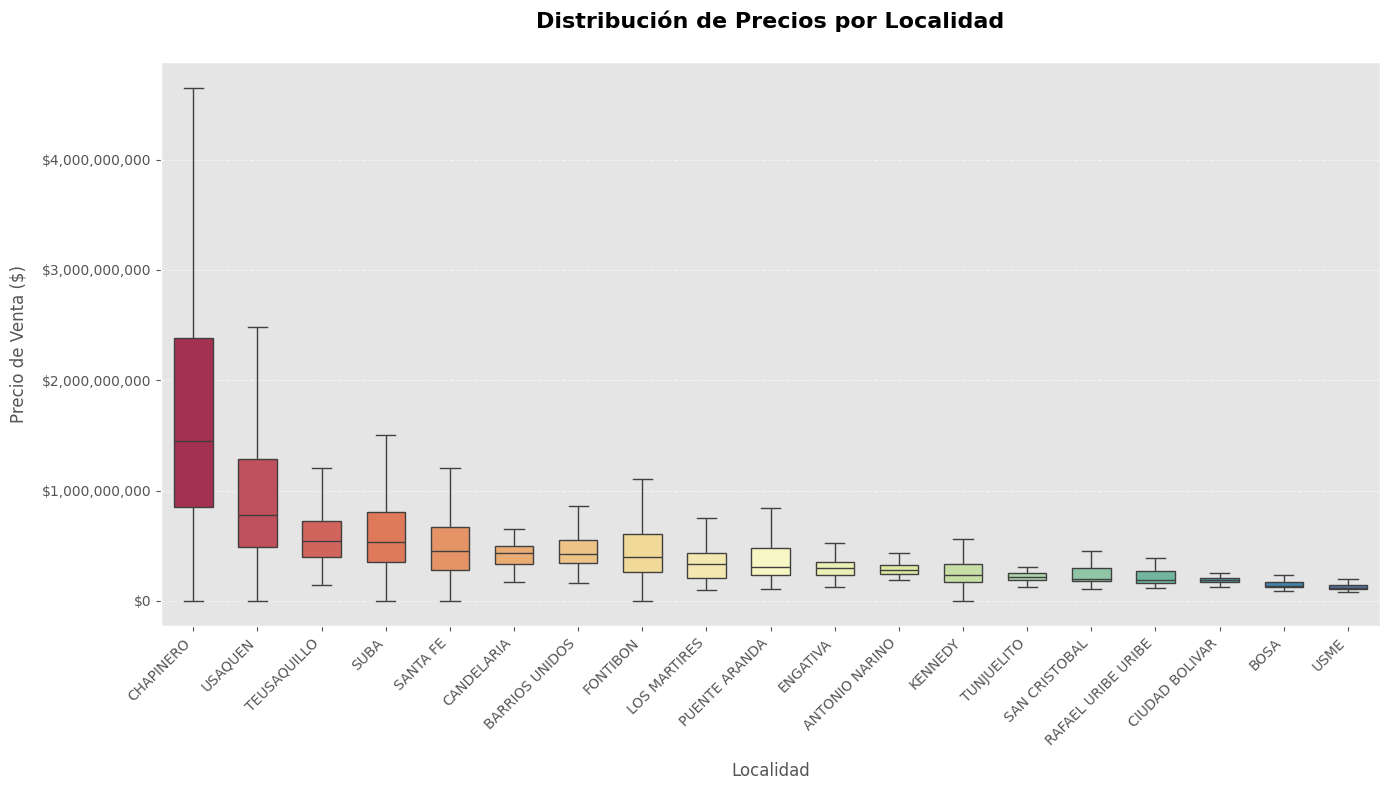

In [36]:


# 1. Preparar los datos: Ordenar de mayor a menor precio promedio
orden_localidad = df.groupby('localidad')['precio_venta'].median().sort_values(ascending=False).index

# 2. Configurar la figura
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Crear el Box Plot
sns.boxplot(
    x='localidad',
    y='precio_venta',
    data=df,
    order=orden_localidad,
    palette='Spectral', # Usamos una paleta variada para las múltiples localidades
    width=0.6,
    showfliers=False,   # Cambiado a False para que los precios extremos no aplasten el gráfico
    ax=ax
)

# 4. Personalizar el gráfico
ax.set_title('Distribución de Precios por Localidad',
             fontsize=16,
             fontweight='bold',
             pad=25)

# Formatear eje Y como moneda (ej: $1,000,000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Personalizar etiquetas
ax.set_xlabel('Localidad', fontsize=12, labelpad=10)
ax.set_ylabel('Precio de Venta ($)', fontsize=12, labelpad=10)

# Rotar etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

# Añadir grid suave
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 5. Ajustar y mostrar
plt.tight_layout()
plt.show()

## Antigüedad VS Precio

In [37]:

# Agrupamos por antigüedad y sacamos el promedio de precio_venta
resumen_antiguedad = df.groupby('antiguedad')['precio_venta'].mean()

# Ordenamos lógicamente (de más nuevo a más antiguo)
orden_logico = ['ENTRE 0 Y 5 ANOS', 'ENTRE 5 Y 10 ANOS', 'ENTRE 10 Y 20 ANOS', 'MAS DE 20 ANOS']
resumen_antiguedad = resumen_antiguedad.reindex(orden_logico)

print("💰 Precio de Venta Promedio por Antigüedad:")
print(resumen_antiguedad.apply(lambda x: f"${x:,.0f}"))

💰 Precio de Venta Promedio por Antigüedad:
antiguedad
ENTRE 0 Y 5 ANOS      $2,530,592,846
ENTRE 5 Y 10 ANOS     $3,012,758,723
ENTRE 10 Y 20 ANOS    $2,935,108,158
MAS DE 20 ANOS        $1,485,956,326
Name: precio_venta, dtype: object


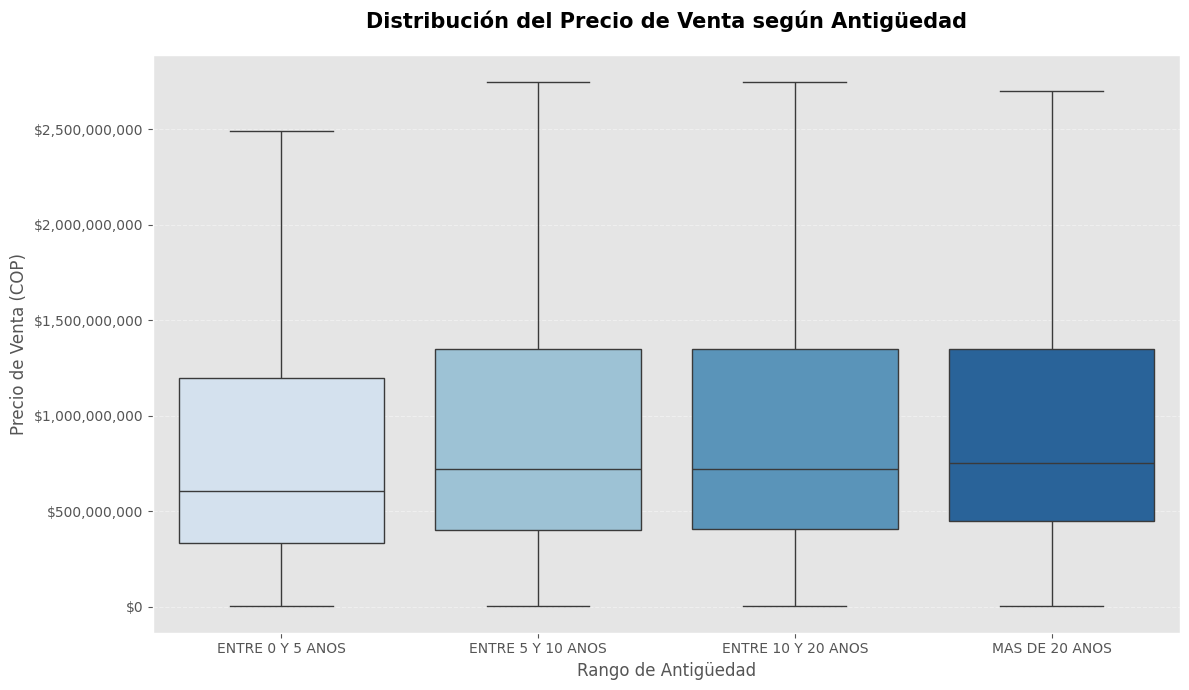

In [38]:

# Configuración de estilo
fig, ax = plt.subplots(figsize=(12, 7))

# Crear el Box Plot
sns.boxplot(
    x='antiguedad',
    y='precio_venta',
    data=df,
    order=orden_logico,
    palette='Blues',
    showfliers=False,  # Quitamos los valores extremos para ver mejor las cajas
    ax=ax
)

# Personalización profesional
ax.set_title('Distribución del Precio de Venta según Antigüedad',
             fontsize=15, fontweight='bold', pad=20)

# Formatear eje Y como moneda
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Etiquetas
ax.set_xlabel('Rango de Antigüedad', fontsize=12)
ax.set_ylabel('Precio de Venta (COP)', fontsize=12)

# Grid de apoyo
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#  Correlación de Mapa de Calor   (Heatmap)

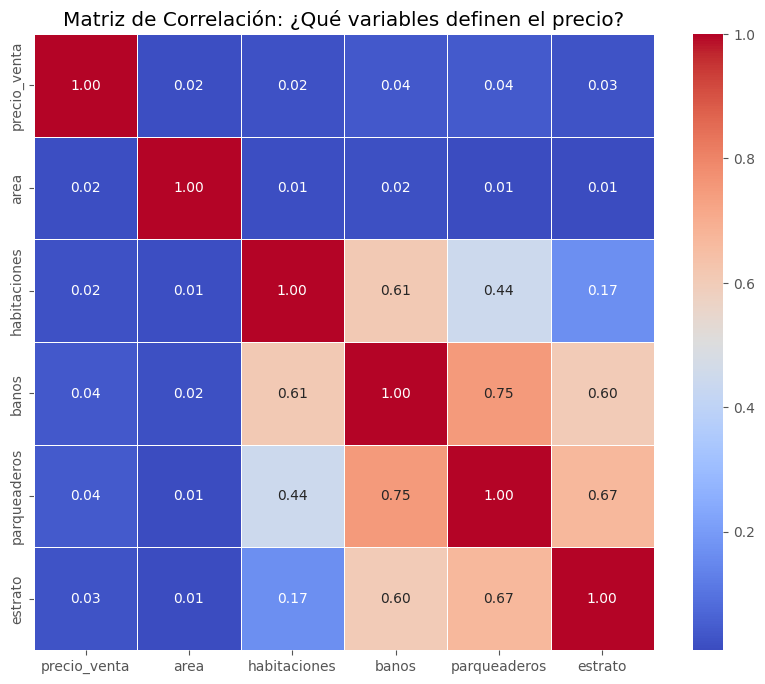

In [39]:

# 1. Reemplazamos el texto ruidoso por NaN real en TODA la tabla
df = df.replace({"{'$numberDouble': 'NaN'}": np.nan}, regex=False)

# 2. Aseguramos que las columnas de interés sean numéricas
# 'coerce' convierte cualquier texto que se haya escapado en un nulo (NaN)
cols_interes = ['precio_venta', 'area', 'habitaciones', 'banos', 'parqueaderos', 'estrato']

for col in cols_interes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Ahora sí, calculamos la correlación ignorando los nulos
corr = df[cols_interes].corr()

# 4. Graficamos el Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: ¿Qué variables definen el precio?')
plt.show()

## Todas las variables categoricas VS Precio

1.   Elemento de la lista
2.   Elemento de la lista



# Recodificación de Variables para modelado

In [40]:
df.head()

,precio_venta,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,antiguedad,tipo_operacion,antiguedad_num
0,339000000.0,76.0,3.0,2.0,1.0,3.0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,ENTRE 10 Y 20 ANOS,VENTA,15.0
1,223000000.0,63.0,3.0,2.0,0.0,3.0,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,MAS DE 20 ANOS,VENTA,25.0
2,440898168.0,54.0,3.0,2.0,0.0,3.0,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,ENTRE 0 Y 5 ANOS,VENTA,2.5
3,158000000.0,43.0,2.0,2.0,0.0,2.0,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,ENTRE 10 Y 20 ANOS,VENTA,15.0
4,222800000.0,48.0,3.0,2.0,0.0,3.0,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,MAS DE 20 ANOS,VENTA,25.0


In [41]:
df.dtypes

,0
precio_venta,float64
area,float64
habitaciones,float64
banos,float64
parqueaderos,float64
estrato,float64
tipo_propiedad,object
localidad,object
sector,object
barrio,object


# Entrenamiento y testeo

### Reparto de datos en entrenamiento y prueba

En esta etapa, separamos los datos en dos conjuntos: **train** (entrenamiento) y **test** (prueba). Esta división es esencial para evaluar el rendimiento del modelo y prevenir el sobreajuste (**overfitting**).

#### **¿Por qué es importante dividir los datos?**
1. **Entrenamiento del modelo:**  
   El conjunto de entrenamiento se utiliza para que el modelo aprenda los patrones y relaciones en los datos.

2. **Evaluación del modelo:**  
   El conjunto de prueba permite medir qué tan bien el modelo generaliza a datos nuevos, garantizando que el rendimiento del modelo no sea únicamente válido para los datos ya conocidos.

3. **Evitar el sobreajuste:**  
   Si no se realiza esta división, es posible que el modelo memorice los datos de entrenamiento, lo que llevaría a un mal rendimiento cuando se enfrente a datos desconocidos.

---

#### **División de los datos con `train_test_split`**

Utilizamos el siguiente comando para realizar la partición de los datos:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('precio', axis='columns'),
    df['precio'],
    train_size=0.8,
    random_state=1234,
    shuffle=True
)



* df.drop('precio', axis='columns'): Se eliminan los valores de la variable objetivo (precio) del conjunto de características.

* df['precio']: Se selecciona la variable objetivo que queremos predecir.

* train_size=0.8: Define que el 80% de los datos se utilizará para entrenamiento y el 20% restante para prueba.

* random_state=1234: Establece una semilla aleatoria para que la partición de datos sea reproducible.

* shuffle=True: Indica que los datos se deben mezclar antes de dividirlos, lo que ayuda a mejorar la representatividad de ambos conjuntos.

In [42]:
df

,precio_venta,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,antiguedad,tipo_operacion,antiguedad_num
0,3.390000e+08,76.00,3.0,2.0,1.0,3.0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,ENTRE 10 Y 20 ANOS,VENTA,15.0
1,2.230000e+08,63.00,3.0,2.0,0.0,3.0,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,MAS DE 20 ANOS,VENTA,25.0
2,4.408982e+08,54.00,3.0,2.0,0.0,3.0,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,ENTRE 0 Y 5 ANOS,VENTA,2.5
3,1.580000e+08,43.00,2.0,2.0,0.0,2.0,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,ENTRE 10 Y 20 ANOS,VENTA,15.0
4,2.228000e+08,48.00,3.0,2.0,0.0,3.0,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,MAS DE 20 ANOS,VENTA,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43008,1.900000e+08,49.00,3.0,2.0,0.0,2.0,APARTAMENTO,SUBA,SUBA,URB. OVIEDO,ENTRE 10 Y 20 ANOS,VENTA,15.0
43009,3.220000e+08,66.00,3.0,2.0,1.0,4.0,APARTAMENTO,SUBA,EL RINCON,LOS TEJARES DE SUBA (PREDIO),ENTRE 10 Y 20 ANOS,VENTA,15.0
43010,3.300000e+08,90.00,3.0,2.0,0.0,4.0,APARTAMENTO,TEUSAQUILLO,LA SOLEDAD,LAS AMERICAS,MAS DE 20 ANOS,VENTA,25.0
43011,1.280000e+09,157.00,3.0,3.0,3.0,6.0,APARTAMENTO,USAQUEN,SANTA BARBARA,S.C. SAN NORTE,MAS DE 20 ANOS,VENTA,25.0


In [43]:
df.shape

(43013, 13)

In [44]:
# Reparto de datos en train y test
# ==============================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop('precio', axis = 'columns'),
                                        df['precio'],
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

KeyError: "['precio'] not found in axis"

In [ ]:
X_train

In [ ]:
X_test

In [ ]:
y_train

In [ ]:
y_test

In [ ]:
X_train

### Validación de la distribución en los conjuntos de entrenamiento y prueba

Una vez que se realiza la división de los datos, es crucial validar que la distribución de los datos en los conjuntos de **entrenamiento** y **prueba** sea similar. Esto garantiza que ambos conjuntos sean representativos del comportamiento general de la variable objetivo (*precio* en este caso). Si las distribuciones difieren demasiado, es posible que el modelo no pueda generalizar correctamente.

#### **¿Por qué es importante validar la distribución?**
1. **Generalización del modelo:**  
   Si la distribución del conjunto de entrenamiento difiere significativamente de la del conjunto de prueba, el modelo puede aprender patrones que no reflejan correctamente los datos nuevos, lo que lleva a un mal rendimiento.

2. **Evitar sesgos en el modelo:**  
   Una diferencia en la distribución puede generar sesgos, haciendo que el modelo se adapte únicamente a los datos de entrenamiento.

3. **Consistencia en la evaluación:**  
   Al asegurar una distribución similar, la evaluación del modelo será más confiable, ya que los resultados obtenidos en el conjunto de prueba reflejarán con mayor precisión el rendimiento esperado en un entorno de producción.



In [ ]:
print("Partición de entrenamento")
print("-----------------------")
print(y_train.describe())

In [ ]:
print("Partición de test")
print("-----------------------")
print(y_test.describe())

In [ ]:
import matplotlib.pyplot as plt

# Calcular estadísticas descriptivas
y_train_stats = y_train.describe()
y_test_stats = y_test.describe()

# Extraer las estadísticas clave para la gráfica
categories = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
y_train_values = [y_train_stats[stat] for stat in categories]
y_test_values = [y_test_stats[stat] for stat in categories]

# Crear una gráfica comparativa
plt.figure(figsize=(10, 6))
plt.plot(categories, y_train_values, marker='o', label='Train', linestyle='-', linewidth=2)
plt.plot(categories, y_test_values, marker='s', label='Test', linestyle='--', linewidth=2)

# Configurar detalles de la gráfica
plt.title('Comparación de la distribución entre train y test (variable respuesta)')
plt.xlabel('Estadística')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd

# Combinar los datos en un DataFrame para Seaborn
df = pd.DataFrame({
    'Valor': y_train.tolist() + y_test.tolist(),
    'Conjunto': ['Train'] * len(y_train) + ['Test'] * len(y_test)
})

# Crear el boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Conjunto', y='Valor', data=df, palette='Set2')

# Configurar detalles de la gráfica
plt.title('Comparación de Boxplot entre Train y Test')
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Codificación y transformación adecuada de las variables

Es fundamental transformar correctamente las variables antes de entrenar un modelo de machine learning. Esto se debe a que los algoritmos suelen requerir un formato de entrada específico para funcionar correctamente. En este caso, aplicamos dos tipos de transformaciones: **escalado de variables numéricas** y **codificación de variables categóricas**.

#### **¿Por qué es importante hacer esto?**

1. **Escalado de variables numéricas:**  
   Las variables numéricas pueden tener diferentes rangos. Si no se escalan, las variables con rangos mayores podrían dominar el aprendizaje del modelo, afectando el rendimiento. Al aplicar el escalado con `StandardScaler()`, centramos los datos en una media de 0 y una desviación estándar de 1, mejorando la convergencia de algunos algoritmos como regresión lineal, k-means o redes neuronales.

2. **Codificación de variables categóricas:**  
   Los modelos de machine learning no pueden trabajar directamente con datos categóricos. Por lo tanto, es necesario convertir estas variables a un formato numérico. En este caso, se utiliza `OneHotEncoder()` para crear una columna binaria para cada categoría, permitiendo al modelo interpretar la información correctamente.

3. **Estandarización del flujo de trabajo:**  
   Utilizar un `ColumnTransformer` permite aplicar distintas transformaciones a diferentes tipos de variables en un solo paso, lo que mejora la reproducibilidad y el mantenimiento del código.


In [ ]:
# Selección de las variables por tipo
# ==============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector

# Se estandarizan las columnas numéricas y se hace one-hot-encoding de las
# columnas cualitativas. Para mantener las columnas a las que no se les aplica
# ninguna transformación se tiene que indicar remainder='passthrough'.

numeric_cols = X_train.select_dtypes(include=['float64', 'int']).columns.to_list()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

In [ ]:
numeric_cols

In [ ]:
cat_cols

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Configuración del preprocesador
preprocessor = ColumnTransformer(
    [
        # Primera transformación: Escalado de las variables numéricas
        # 'scale' es un nombre arbitrario para identificar esta transformación
        ('scale', StandardScaler(), numeric_cols),

        # Segunda transformación: Codificación de las variables categóricas (One-hot encoding)
        # 'onehot' es un nombre arbitrario para esta transformación
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],

    # Indica que las columnas que no se especifican en 'numeric_cols' o 'cat_cols'
    # deben mantenerse sin cambios (passthrough)
    remainder='passthrough',

    # Desactiva el agregado de prefijos en los nombres de las columnas de salida
    verbose_feature_names_out=False
).set_output(transform="pandas")  # Configura la salida para que sea un DataFrame de pandas

# ------------------------------------------------------------
# Aplicar el preprocesador a los datos de entrenamiento
# ------------------------------------------------------------
# El método fit_transform() ajusta el preprocesador a los datos de entrenamiento
# y luego transforma estos datos según las reglas definidas anteriormente.
X_train_prep = preprocessor.fit_transform(X_train)

# ------------------------------------------------------------
# Aplicar el preprocesador a los datos de prueba
# ------------------------------------------------------------
# El método transform() aplica las mismas transformaciones a los datos de prueba,
# utilizando los parámetros aprendidos en el conjunto de entrenamiento.
X_test_prep = preprocessor.transform(X_test)

# ------------------------------------------------------------
# Visualización de los primeros registros transformados
# ------------------------------------------------------------
# Muestra las primeras 3 filas de los datos preprocesados de entrenamiento.
X_train_prep.head(3)


In [ ]:
X_test_prep.head()

# Que guarda el procesador ?

### Para Variables numérica

In [ ]:
# Acceder al StandardScaler en el preprocesador
scaler = preprocessor.named_transformers_['scale']

# Mostrar la media y desviación estándar que ha aprendido el scaler
media = scaler.mean_
desviacion = scaler.scale_

print("Media aprendida por StandardScaler:")
print(pd.Series(media, index=numeric_cols))

print("\nDesviación estándar aprendida por StandardScaler:")
print(pd.Series(desviacion, index=numeric_cols))

## Para Variables Categóricas

In [ ]:
# Acceder al OneHotEncoder en el preprocesador
encoder = preprocessor.named_transformers_['onehot']

# Mostrar las categorías detectadas para cada variable categórica
print("Categorías aprendidas por OneHotEncoder:")
for col, categories in zip(cat_cols, encoder.categories_):
    print(f"{col}: {categories}")

# Diagrama de cada paso aplicado

In [ ]:
from sklearn import set_config
set_config(display='diagram')

preprocessor

# Guardar el codificador para nuevos casos

In [ ]:
# Importar la biblioteca para guardar y cargar objetos
import joblib

# -------------------------------
# Guardar el preprocesador
# -------------------------------
# Guardar el preprocesador en un archivo .pkl
joblib.dump(preprocessor, 'preprocessor_saratoga.pkl')

print("Preprocesador guardado exitosamente en 'preprocessor_saratoga.pkl'.")

In [ ]:
# Cargar el preprocesador guardado
loaded_preprocessor = joblib.load('preprocessor_saratoga.pkl')

In [ ]:
# Simulación de nuevos datos (puedes reemplazarlo con datos reales)
# Simulación de nuevos datos
nuevos_datos = pd.DataFrame({
    'metros_habitables': [1000, 1800],
    'banyos': [1.5, 2.0],
    'precio_terreno': [12000, 25000],
    'Acres_totales': [0.12, 0.5],
    'habitaciones': [4, 5],
    'chimenea': ['No tiene', 'Tiene'],
    'categoria_antiguedad': ['Media', 'Nueva'],
    'aire_acondicionado': ['No', 'Yes'],
    'desague': ['public/commercial', 'septic'],
    'calefaccion': ['hot air', 'electric'],
    'consumo_calefacion': ['gas', 'electric']
})

# Aplicar el preprocesador cargado a los nuevos datos
nuevos_datos_prep = loaded_preprocessor.transform(nuevos_datos)

# Mostrar los primeros registros de los datos transformados
print("Datos transformados:")
nuevos_datos_prep.head()

In [ ]:
import session_info
session_info.show(html=False)